# Step 0-1: 라이브러리 설치 및 임포트

In [15]:
!pip install wordcloud

In [16]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import nltk
import os
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gyu61\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gyu61\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\gyu61\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# Step 0-2: HTML 구조 탐색 (크롤링 전 분석)

🔍 브라우저에서 HTML 구조 직접 확인하기


1️⃣ 브라우저에서 아래 URL 접속
   👉 https://en.wikipedia.org/wiki/Machine_learning

2️⃣ 개발자 도구 열기
   - Windows: F12 또는 Ctrl + Shift + I
   - Mac: Cmd + Option + I

3️⃣ Elements 탭에서 본문 텍스트 찾기
   - 본문 문단 위에서 마우스 우클릭 → "검사" 클릭
   - 해당 요소의 태그와 상위 구조 확인

4️⃣ 아래 질문에 답해보세요:

   Q1. 본문 문단은 어떤 태그로 감싸져 있나요?

   Q2. 본문 영역을 감싸는 상위 `<div>`의 id는 무엇인가요?

   Q3. 본문만 정확히 가져오려면 어떤 CSS 선택자를 써야 할까요?

In [17]:
import requests
from bs4 import BeautifulSoup

url = "https://en.wikipedia.org/wiki/Machine_learning"
headers = {"User-Agent": "Mozilla/5.0"}

res = requests.get(url, headers=headers)
soup = BeautifulSoup(res.text, "html.parser")

all_p = soup.find_all("p")  # 👈 여기를 채우세요!
print(f"전체 <p> 태그 개수: {len(all_p)}개")

first_p = soup.find("p")  # 👈 여기를 채우세요!
print(first_p.get_text()[:300])

content_p = soup.select("#mw-content-text")  # 👈 여기를 채우세요!
print(f"본문 <p> 태그 개수: {len(content_p)}개")
print(f"\n첫 번째 문단:\n{content_p[0].get_text()[:300]}")

전체 <p> 태그 개수: 114개


본문 <p> 태그 개수: 1개

첫 번째 문단:

Study of algorithms that improve automatically through experience
For the journal, see Machine Learning (journal).
"Statistical learning" redirects here. For statistical learning in linguistics, see Statistical learning in language acquisition.


Part of a series onMachine learningand data mining
P


# Step 1: Wikipedia 100개 문서 크롤링
## Step 1-1: Wikipedia 랜덤 제목 100개 수집

In [18]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

headers = {
    "User-Agent": "Mozilla/5.0"
}

url = "https://en.wikipedia.org/w/api.php"

# API 파라미터 설정
# 참고: https://www.mediawiki.org/wiki/API:Random
params = {
    "action": "query",
    "format": "json",
    "list": "random",
    "rnnamespace": 0,
    "rnlimit": 100 # 👈 여기를 채우세요!
}

response = requests.get(url, params=params, headers=headers)

data = response.json()

print(data)

{'batchcomplete': '', 'continue': {'rncontinue': '0.315122095584|0.315137488945|7952440|0', 'continue': '-||'}, 'query': {'random': [{'id': 5000815, 'ns': 0, 'title': 'Enfield, County Meath'}, {'id': 17023947, 'ns': 0, 'title': 'Viktor Lowenfeld'}, {'id': 16001073, 'ns': 0, 'title': 'Yugoslav Olympic Committee'}, {'id': 58060691, 'ns': 0, 'title': 'József Sátori'}, {'id': 64782480, 'ns': 0, 'title': 'Luang Prabang montane rain forests'}, {'id': 40883758, 'ns': 0, 'title': 'Hajjiabad, Amol'}, {'id': 15734318, 'ns': 0, 'title': 'William Wedderburn (Canadian politician)'}, {'id': 5207311, 'ns': 0, 'title': 'Heroes (American TV series)'}, {'id': 4411743, 'ns': 0, 'title': "Marjolin's ulcer"}, {'id': 7199095, 'ns': 0, 'title': 'Regina Blues'}, {'id': 54217733, 'ns': 0, 'title': 'Alastor sulcatus'}, {'id': 34028985, 'ns': 0, 'title': 'Kevin Harley'}, {'id': 23785175, 'ns': 0, 'title': 'John McGill (bishop)'}, {'id': 14017394, 'ns': 0, 'title': 'Carl Plötz'}, {'id': 24770210, 'ns': 0, 'title'

In [19]:
# 위에서 출력한 JSON 구조를 보고, title만 추출하세요
titles = [item["title"] for item in data["query"]["random"]] # 👈 여기를 채우세요!

print("수집된 문서 수:", len(titles))
print("예시 제목:", titles[:5])

수집된 문서 수: 100
예시 제목: ['Enfield, County Meath', 'Viktor Lowenfeld', 'Yugoslav Olympic Committee', 'József Sátori', 'Luang Prabang montane rain forests']


## Step 1-2: 각 Wikipedia 페이지 본문(content) 크롤링

In [20]:
texts = []
refs = []

for title in titles:
    page_url = f"https://en.wikipedia.org/wiki/{title.replace(' ', '_')}"
    res = requests.get(page_url, headers=headers)
    soup = BeautifulSoup(res.text, "html.parser")

    # References 섹션 따로 추출 (decompose 전에!)
    ref_tags = soup.select(".reflist, .references")
    ref_text = " ".join([r.get_text() for r in ref_tags])

    # References 섹션 제거 후 본문 추출
    for tag in ref_tags:
        tag.decompose()

    paragraphs = soup.select("#mw-content-text p")  # 👈 여기를 채우세요!
    main_text = " ".join([p.get_text() for p in paragraphs])

    texts.append(main_text)
    refs.append(ref_text)

## Step 1-3: 데이터프레임 생성

In [21]:
df = pd.DataFrame({
    "title": titles,
    "content": texts,
    "references": refs
})

df.head()

,title,content,references
0,"Enfield, County Meath","\n Enfield (Irish: An Bóthar Buí, meaning 'the...","\n^ a b ""Census 2022 - F1015 Population"". Cent..."
1,Viktor Lowenfeld,Austrian Viktor Lowenfeld (1903–1960) was an A...,"\n^ Douglas C. Allen. ""United States of Americ..."
2,Yugoslav Olympic Committee,The Yugoslav Olympic Committee (Croatian: Jugo...,"\n^ ""JOK postao Olimpijski komitet Srbije i Cr..."
3,József Sátori,\n József Sátori (25 February 1926 – 23 Februa...,"\n^ a b Evans, Hilary; Gjerde, Arild; Heijmans..."
4,Luang Prabang montane rain forests,The Luang Prabang montane rain forests ecoregi...,"\n^ a b ""Luang Prabang montane rain forests"". ..."


## Step 1-4: 데이터 확인

In [22]:
print("총 문서 수:", len(df))
print("첫 번째 문서 길이:", len(df["content"][0]))

총 문서 수: 100
첫 번째 문서 길이: 7302


# Step 2: 텍스트 전처리(Cleaning) 목표
## Step 2-1: 소문자 변환
## Step 2-2: citation 제거
## Step 2-3: 특수문자 제거
## Step 2-4: 숫자 제거

In [23]:
import re

def clean_text(text):
    # 소문자 변환
    text = text.lower() # 👈 여기를 채우세요!

    # [edit], [update] 같은 위키 태그 제거  ← 추가
    text = re.sub(r'\[edit\]', ' ', text)
    
    # [1], [2] 같은 citation 제거
    text = re.sub(r'\[\d+\]', ' ', text) # 👈 여기를 채우세요!

    # 특수문자/숫자 제거
    text = re.sub(r'[^a-z\s]', ' ', text) # 👈 여기를 채우세요!

    return text

df["clean_text"] = df["content"].apply(clean_text)
df[["content","clean_text"]].head(3)

,content,clean_text
0,"\n Enfield (Irish: An Bóthar Buí, meaning 'the...",\n enfield irish an b thar bu meaning the...
1,Austrian Viktor Lowenfeld (1903–1960) was an A...,austrian viktor lowenfeld was an a...
2,The Yugoslav Olympic Committee (Croatian: Jugo...,the yugoslav olympic committee croatian jugo...


# Step 3: Tokenization + Stopwords 제거



In [24]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# 영어 불용어 리스트 로드
stop_words = set(stopwords.words("english"))

def tokenize(text):
    # 토큰화
    tokens = word_tokenize(text) # 👈 여기를 채우세요!
    # 불용어 제거 + 길이 2 이하 제거
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2] # 👈 여기를 채우세요!

    return tokens

df["tokens"] = df["clean_text"].apply(tokenize)
df["tokens"].head()

0    [enfield, irish, thar, meaning, yellow, road, ...
1    [austrian, viktor, lowenfeld, austrian, born, ...
2    [yugoslav, olympic, committee, croatian, jugos...
3    [zsef, tori, february, february, hungarian, ro...
4    [luang, prabang, montane, rain, forests, ecore...
Name: tokens, dtype: object

# Step 4: Word Frequency 분석

In [25]:
from collections import Counter
# 모든 토큰을 하나로 합치기
all_words = sum(df["tokens"], [])
all_words

['enfield',
 'irish',
 'thar',
 'meaning',
 'yellow',
 'road',
 'also',
 'known',
 'innfield',
 'town',
 'south',
 'county',
 'meath',
 'ireland',
 'situated',
 'kilcock',
 'kinnegad',
 'close',
 'border',
 'county',
 'kildare',
 'town',
 'dublin',
 'sligo',
 'railway',
 'line',
 'located',
 'regional',
 'road',
 'formerly',
 'national',
 'primary',
 'road',
 'connecting',
 'dublin',
 'connacht',
 'years',
 'census',
 'population',
 'enfield',
 'grew',
 'considerably',
 'inhabitants',
 'people',
 'increase',
 'due',
 'location',
 'commuter',
 'belt',
 'dublin',
 'similarly',
 'many',
 'dormitory',
 'towns',
 'vicinity',
 'numerous',
 'housing',
 'estates',
 'constructed',
 'census',
 'numbers',
 'indicating',
 'town',
 'housing',
 'stock',
 'households',
 'built',
 'census',
 'population',
 'increased',
 'village',
 'irish',
 'name',
 'thar',
 'yellow',
 'road',
 'derived',
 'yellow',
 'mud',
 'formed',
 'main',
 'street',
 'village',
 'combination',
 'rain',
 'churning',
 'effect',
 '

In [26]:
# Counter 사용하여 빈도 계산하기
word_freq = Counter(all_words)
# 상위 20개 단어 출력
word_freq.most_common(20)

[('first', 131),
 ('heroes', 106),
 ('new', 101),
 ('series', 101),
 ('also', 99),
 ('season', 95),
 ('two', 82),
 ('one', 71),
 ('later', 55),
 ('help', 50),
 ('time', 49),
 ('information', 48),
 ('missing', 45),
 ('article', 45),
 ('wikipedia', 45),
 ('adding', 45),
 ('episode', 45),
 ('stub', 44),
 ('used', 43),
 ('born', 43)]

# Step 5: WordCloud 시각화

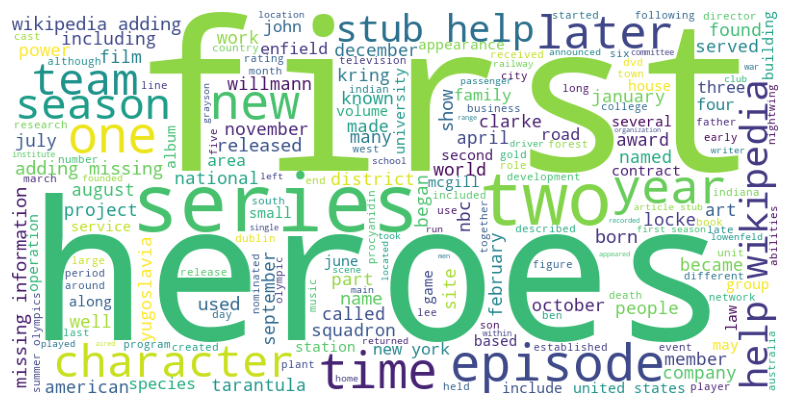

In [27]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(all_words) # 👈 여기를 채우세요!

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text) # 👈 여기를 채우세요!

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

# Step 6: 데이터 저장

In [30]:
df.to_csv("wikipedia_text_dataset.csv", index=False)

os.path.exists("wikipedia_text_dataset.csv")

True

# Step 7: 제공된 PPT 형식에 각 Step 별로 설명하는 내용을 만들어라.
1.   각 Step 별 결과물 스크린샷
2.   해당 Step에서 해당 코드가 적용되는 본인의 간단한 이유
1.   각 Step에 대한 본인만의 분석 결과



